In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Load Dataset

In [32]:
df=pd.read_csv("/content/retail_sales_dataset.csv")

In [3]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [4]:
df.tail()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
995,996,2023-05-16,CUST996,Male,62,Clothing,1,50,50
996,997,2023-11-17,CUST997,Male,52,Beauty,3,30,90
997,998,2023-10-29,CUST998,Female,23,Beauty,4,25,100
998,999,2023-12-05,CUST999,Female,36,Electronics,3,50,150
999,1000,2023-04-12,CUST1000,Male,47,Electronics,4,30,120


In [8]:
df.shape

(1000, 9)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    1000 non-null   int64 
 1   Date              1000 non-null   object
 2   Customer ID       1000 non-null   object
 3   Gender            1000 non-null   object
 4   Age               1000 non-null   int64 
 5   Product Category  1000 non-null   object
 6   Quantity          1000 non-null   int64 
 7   Price per Unit    1000 non-null   int64 
 8   Total Amount      1000 non-null   int64 
dtypes: int64(5), object(4)
memory usage: 70.4+ KB


In [6]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [52]:
print(df[['Age','Quantity','Price per Unit','Total Amount']].median())
print(df[['Age','Quantity','Price per Unit','Total Amount']].mode().iloc[0])

Age                42.0
Quantity            3.0
Price per Unit     50.0
Total Amount      135.0
dtype: float64
Age               43.0
Quantity           4.0
Price per Unit    50.0
Total Amount      50.0
Name: 0, dtype: float64


Median Age is 42, close to the mean — suggesting a fairly symmetric age distribution among customers. Median Total Amount is ₹135, notably lower than the mean, indicating a right-skewed spending distribution — a smaller number of high-value transactions are pulling the average up. Mode Quantity is 4 units, the single most common order size.


In [9]:
df.isnull().sum()

,0
Transaction ID,0
Date,0
Customer ID,0
Gender,0
Age,0
Product Category,0
Quantity,0
Price per Unit,0
Total Amount,0


Converting Date (objects) into DateTime

In [33]:
df['Date']=pd.to_datetime(df['Date'])

In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   Transaction ID    1000 non-null   int64         
 1   Date              1000 non-null   datetime64[ns]
 2   Customer ID       1000 non-null   object        
 3   Gender            1000 non-null   object        
 4   Age               1000 non-null   int64         
 5   Product Category  1000 non-null   object        
 6   Quantity          1000 non-null   int64         
 7   Price per Unit    1000 non-null   int64         
 8   Total Amount      1000 non-null   int64         
dtypes: datetime64[ns](1), int64(5), object(3)
memory usage: 70.4+ KB


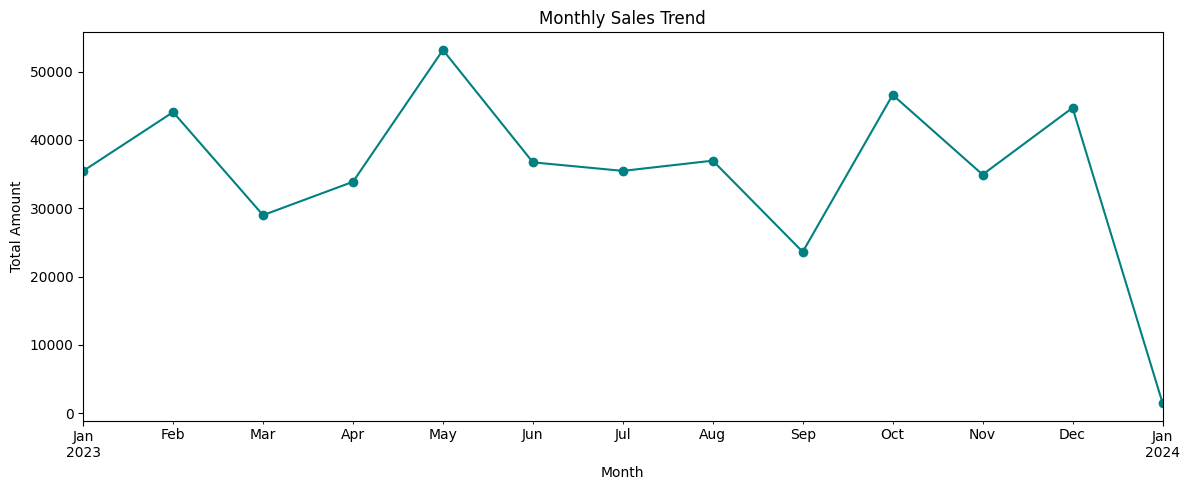

In [53]:
monthly = df.set_index('Date').resample('ME')['Total Amount'].sum()
plt.figure(figsize=(12,5))
monthly.plot(kind='line', marker='o', color='teal')
plt.title('Monthly Sales Trend')
plt.xlabel('Month')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

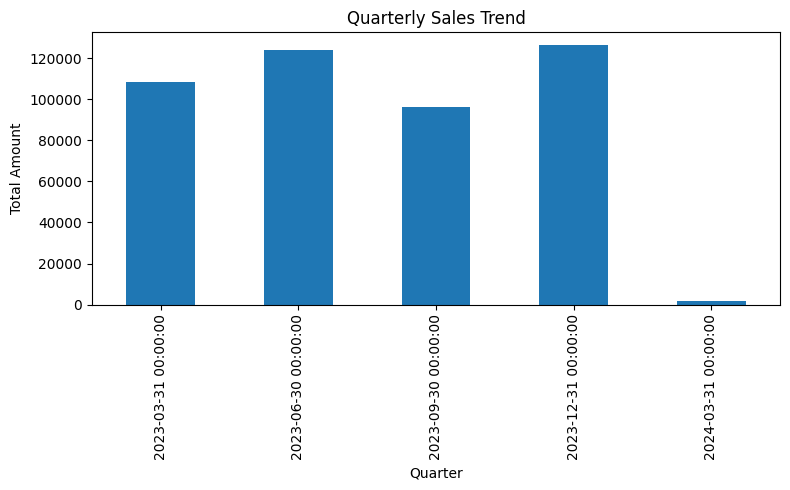

In [54]:
quartly=df.set_index('Date').resample('QE')['Total Amount'].sum()
plt.figure(figsize=(8,5))
quartly.plot(kind='bar')
plt.title('Quarterly Sales Trend')
plt.xlabel('Quarter')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

In [23]:
df.Gender.value_counts()

,count
Gender,
Female,510
Male,490


In [28]:
df.sample(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
337,338,2023-07-26,CUST338,Male,25-35,Beauty,2,50,100
451,452,2023-05-08,CUST452,Female,25-35,Clothing,3,500,1500
987,988,2023-05-28,CUST988,Female,50+,Clothing,3,25,75
312,313,2023-03-21,CUST313,Female,25-35,Beauty,3,500,1500
72,73,2023-08-21,CUST073,Male,18-25,Electronics,3,30,90


In [34]:
df['Age'].dtype

dtype('int64')

In [36]:
df['Age_bin']=pd.cut(
    df['Age'],
    bins=[17,25,40,60,100],
    labels=['18-25','26-40','41-60','60+']
)

/tmp/ipykernel_2825/2126276377.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('Age_bin')['Total Amount'].sum().plot(kind='bar')


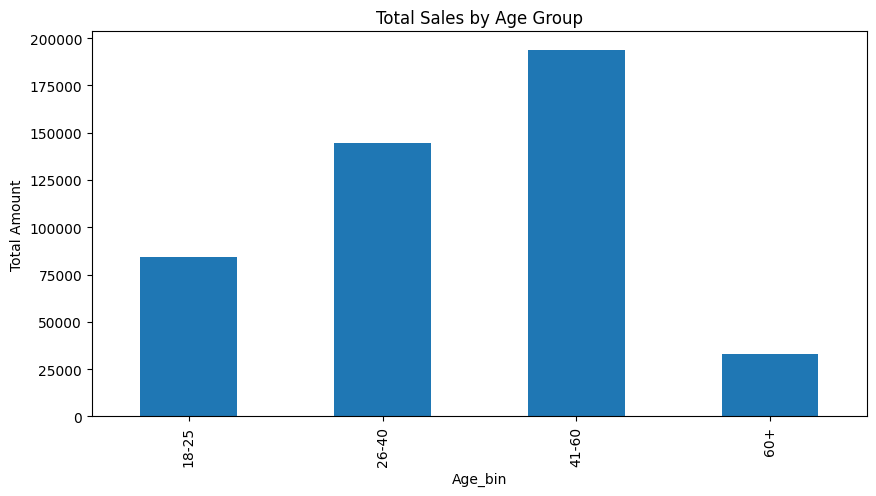

In [40]:

plt.figure(figsize=(10,5))
df.groupby('Age_bin')['Total Amount'].sum().plot(kind='bar')

plt.title('Total Sales by Age Group')
plt.xlabel('Age_bin')
plt.ylabel('Total Amount')
plt.show()

The 41–60 age group drives the most revenue (₹1,93,880), followed by 26–40 (₹1,44,345) — together these two groups account for roughly 73% of total sales despite representing 738 of 1,000 customers. The 60+ group is both the smallest customer base (93 people) and lowest revenue contributor (₹33,225), suggesting limited marketing reach or product-fit in that segment.

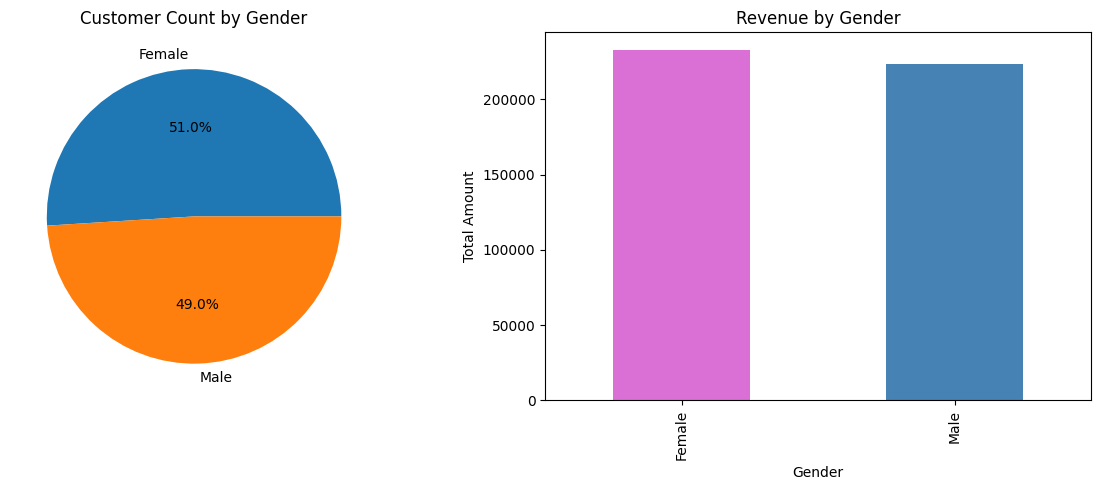

In [55]:
fig, ax = plt.subplots(1, 2, figsize=(12,5))
df['Gender'].value_counts().plot(kind='pie', autopct='%1.1f%%', ax=ax[0])
ax[0].set_title('Customer Count by Gender')
ax[0].set_ylabel('')

df.groupby('Gender')['Total Amount'].sum().plot(kind='bar', ax=ax[1], color=['orchid','steelblue'])
ax[1].set_title('Revenue by Gender')
ax[1].set_ylabel('Total Amount')
plt.tight_layout()
plt.show()

Customers are nearly evenly split — 510 female (51%) vs 490 male (49%) — and revenue follows the same near-parity: ₹2,32,840 from female customers vs ₹2,23,160 from male customers. Gender is not a strong differentiator of spend in this dataset; both segments contribute almost equally to total revenue.


Product analysis: top 10 best-selling products; revenue by product category (bar chart)


In [43]:
df.sample(5)

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Age_bin
119,120,2023-05-07,CUST120,Male,60,Beauty,1,50,50,41-60
617,618,2023-01-26,CUST618,Female,27,Beauty,1,50,50,26-40
177,178,2023-10-04,CUST178,Male,40,Clothing,2,30,60,26-40
864,865,2023-12-21,CUST865,Female,42,Clothing,1,300,300,41-60
694,695,2023-08-12,CUST695,Female,22,Electronics,3,50,150,18-25


In [42]:
df.groupby('Product Category')['Total Amount'].sum()

,Total Amount
Product Category,
Beauty,143515
Clothing,155580
Electronics,156905


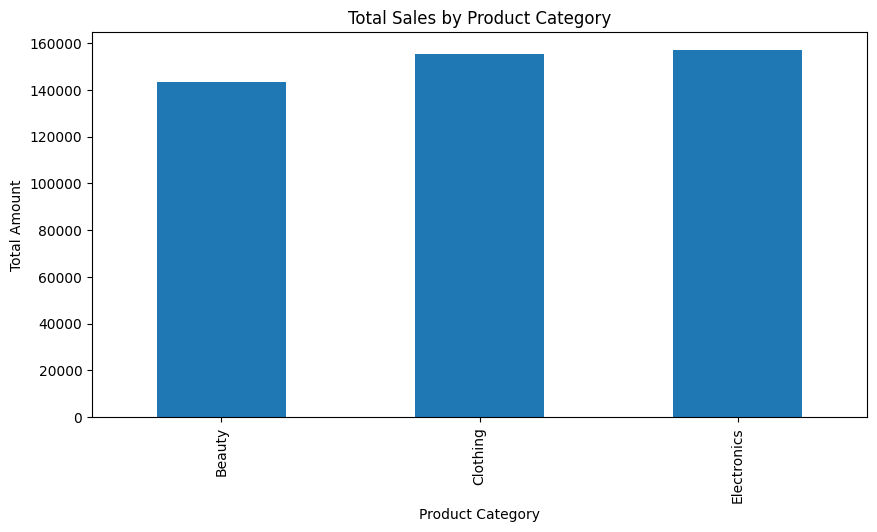

In [44]:
plt.figure(figsize=(10,5))
df.groupby('Product Category')['Total Amount'].sum().plot(kind='bar')
plt.title('Total Sales by Product Category')
plt.xlabel('Product Category')
plt.ylabel('Total Amount')
plt.show()

Revenue is nearly balanced across categories — Electronics (₹1,56,905), Clothing (₹1,55,580), and Beauty (₹1,43,515) are all within ~9% of each other. However, Clothing sells the most units (894) while Electronics sells fewer units (849) yet earns slightly more revenue — confirming Electronics has a higher average price per unit, consistent with the strong Price per Unit ↔ Total Amount correlation (0.85) found in the heatmap.

**Heatmap**: correlation matrix between numerical variables

In [45]:
numeric_cols=['Age','Quantity','Price per Unit','Total Amount']
corr_matrix=df[numeric_cols].corr()

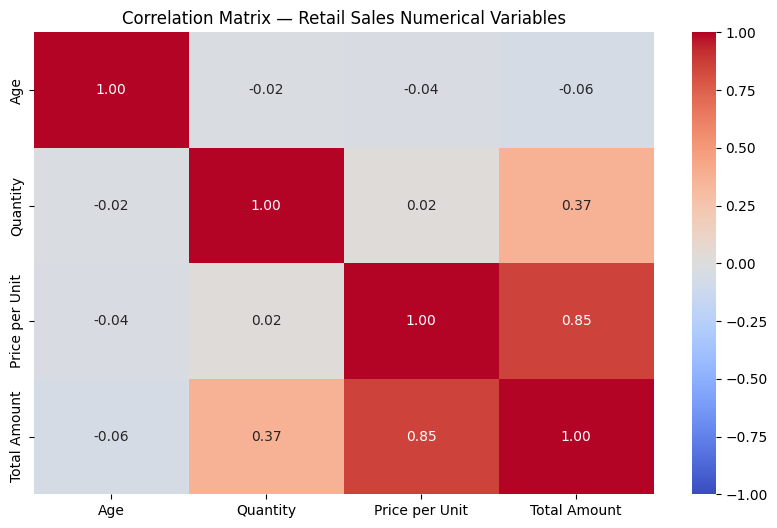

In [49]:
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix,annot=True,cmap='coolwarm',vmin=-1,vmax=1,fmt='.2f')
plt.title('Correlation Matrix — Retail Sales Numerical Variables')
plt.show()

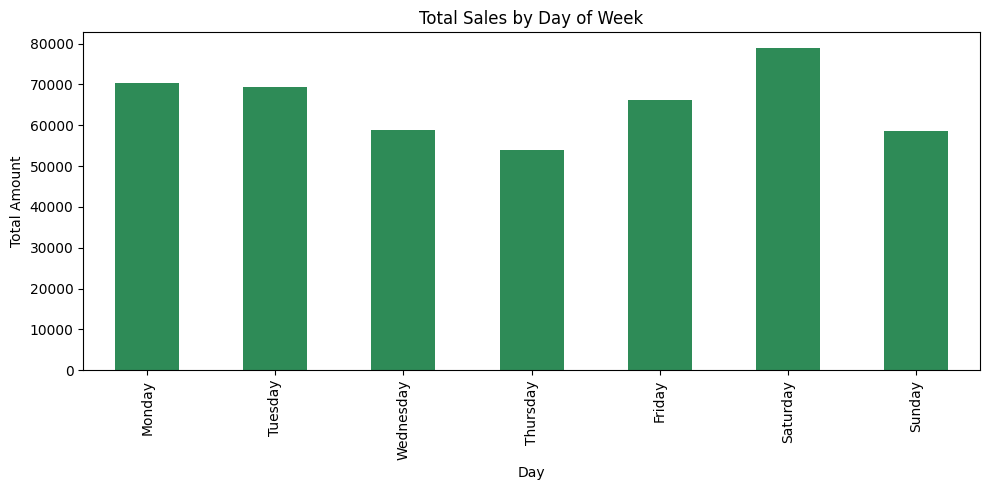

In [56]:
df['DayOfWeek'] = df['Date'].dt.day_name()
order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

plt.figure(figsize=(10,5))
df.groupby('DayOfWeek')['Total Amount'].sum().reindex(order).plot(kind='bar', color='seagreen')
plt.title('Total Sales by Day of Week')
plt.xlabel('Day')
plt.ylabel('Total Amount')
plt.tight_layout()
plt.show()

Saturday is the strongest sales day both in total revenue (₹78,815) and average transaction value (₹525) — noticeably ahead of every other day. Thursday is the weakest (₹53,835 total, ₹438 average). This points to a clear weekend-shopping pattern, useful for timing promotions or staffing.